checking what are the distributions of scans in the data after QA 

In [5]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np

In [6]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')

# combined_df = combined_df[combined_df['tiv'] >= 1000]
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')

combined_df['session_id'] = combined_df['session_id'].astype(str)

# remove 'ses-" "
combined_df['session_id'] = combined_df['session_id'].str.replace(r'^ses-', '', regex=True)

# fill scan_date according to session_id (yyyymmdd) to date format
combined_df['scan_date'] = combined_df['session_id'].apply(
    lambda x: f"{x[:4]}-{x[4:6]}-{x[6:8]}" if len(str(x)) in [8, 12] else None
)
combined_df['scan_year'] = combined_df['scan_date'].apply(lambda x: x.split('-')[0] if x else None)

combined_df['scan_year'] = pd.to_numeric(combined_df['scan_year'], errors='coerce')
 
print(combined_df.columns)

# combined_df.to_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label', 'scan_year'],
      dtype='object')


In [ ]:
# keep only classification_label=1 and snbb
good_scans = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

# remove duplicates based on session_id and subject_id
good_scans = good_scans.drop_duplicates(subset=['session_id', 'subject_id'])

age_windows = [(15, 20),(20, 24), (25, 29), (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59), (60, 64), (65, 69), (70, 74)]

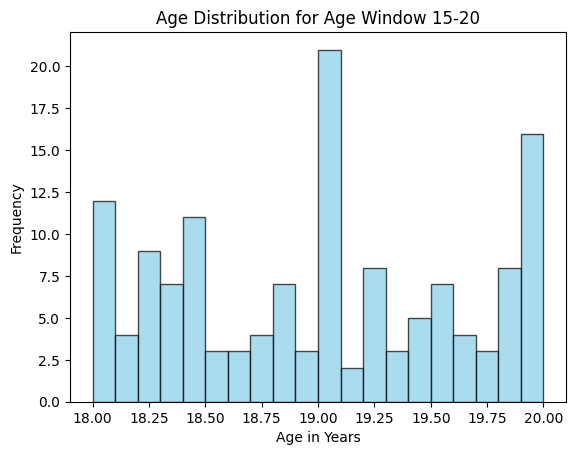

In [9]:
# plot age distribution for age window 15-20
min_age, max_age = 15, 20
filtered_df = good_scans[(good_scans['age_in_years'] >= min_age) & (good_scans['age_in_years'] <= max_age)]
plt.hist(filtered_df['age_in_years'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Age Distribution for Age Window {min_age}-{max_age}')
plt.xlabel('Age in Years')
plt.ylabel('Frequency')
plt.show()

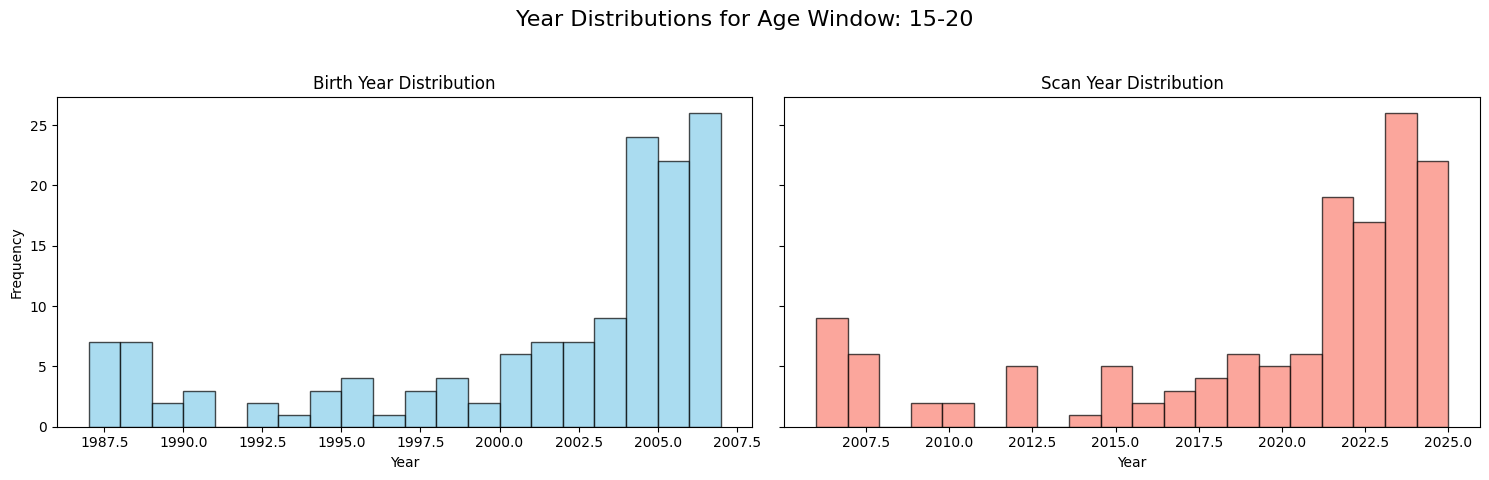

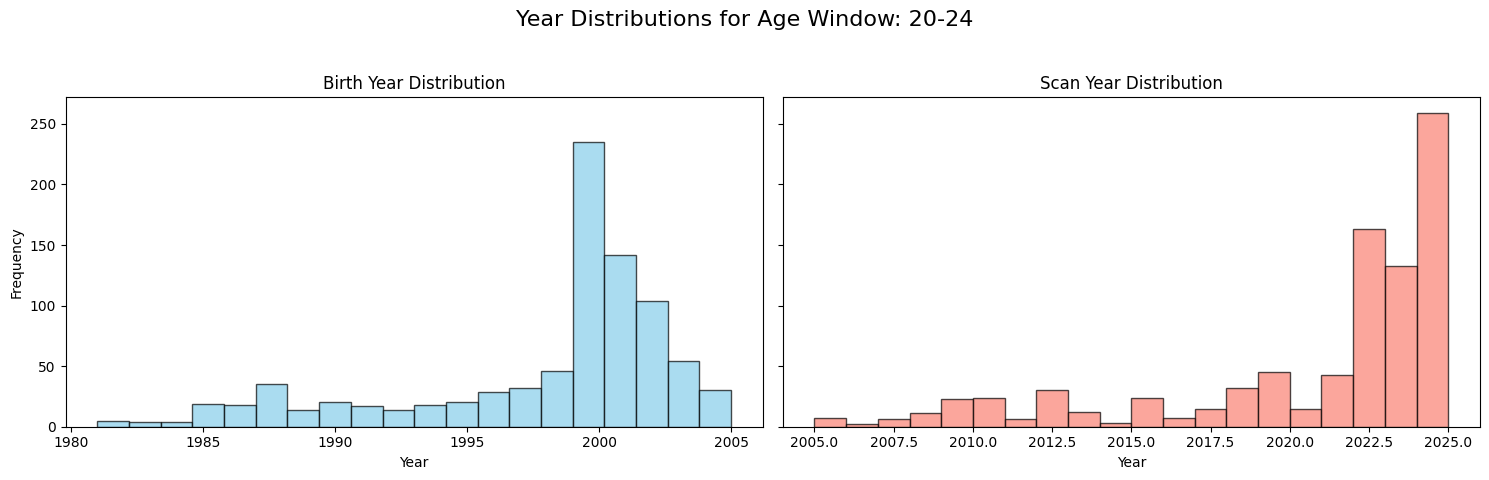

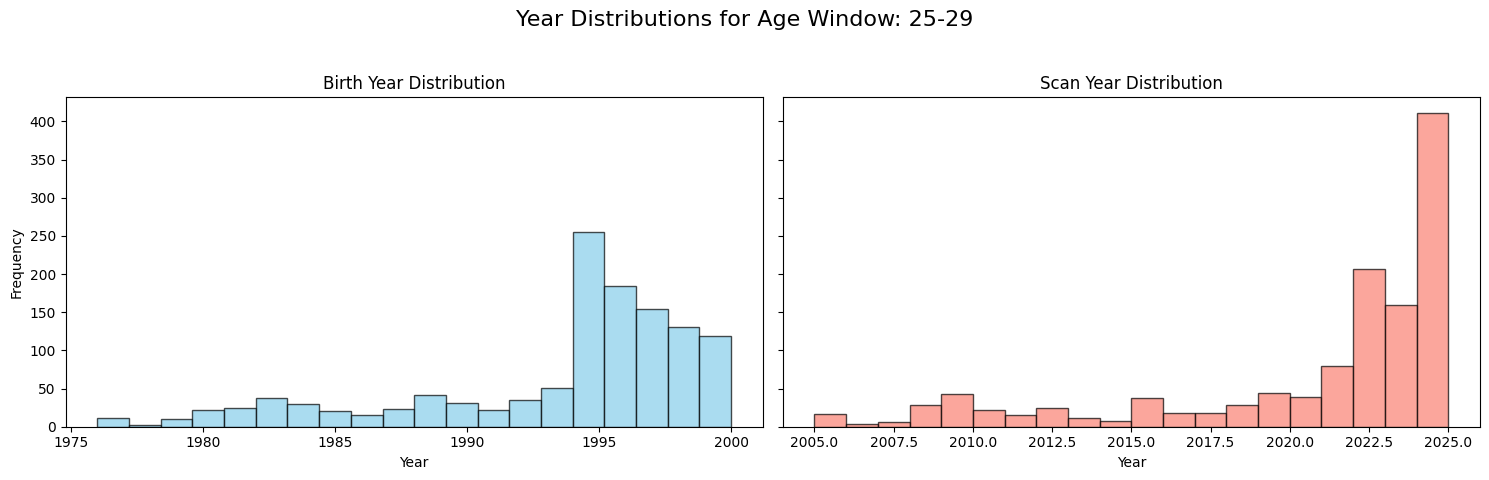

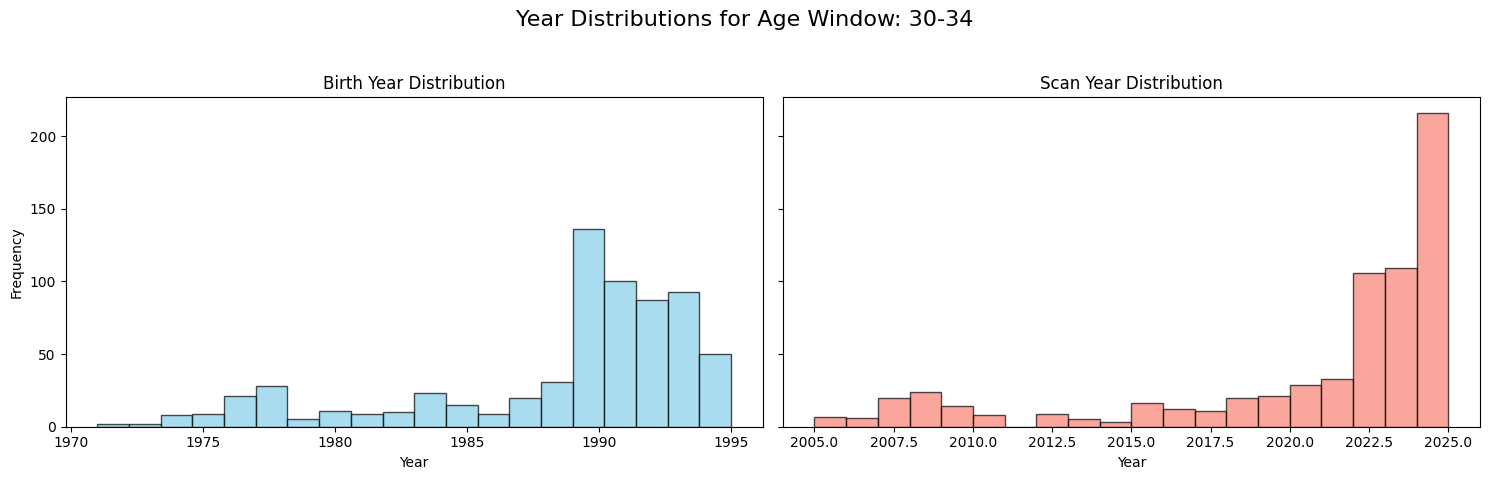

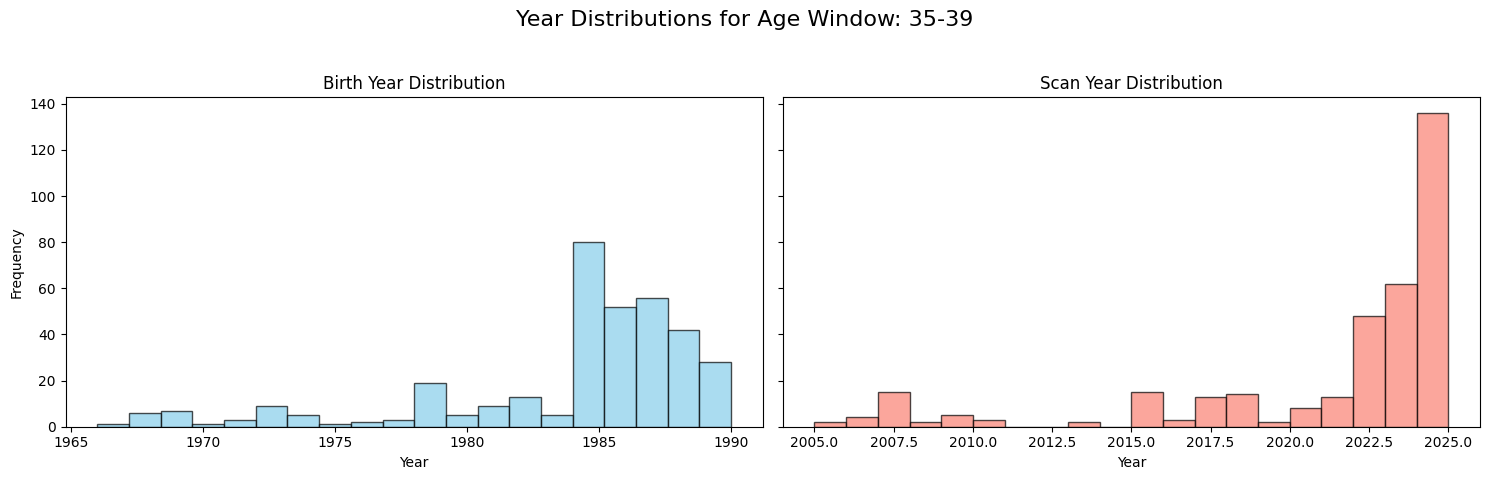

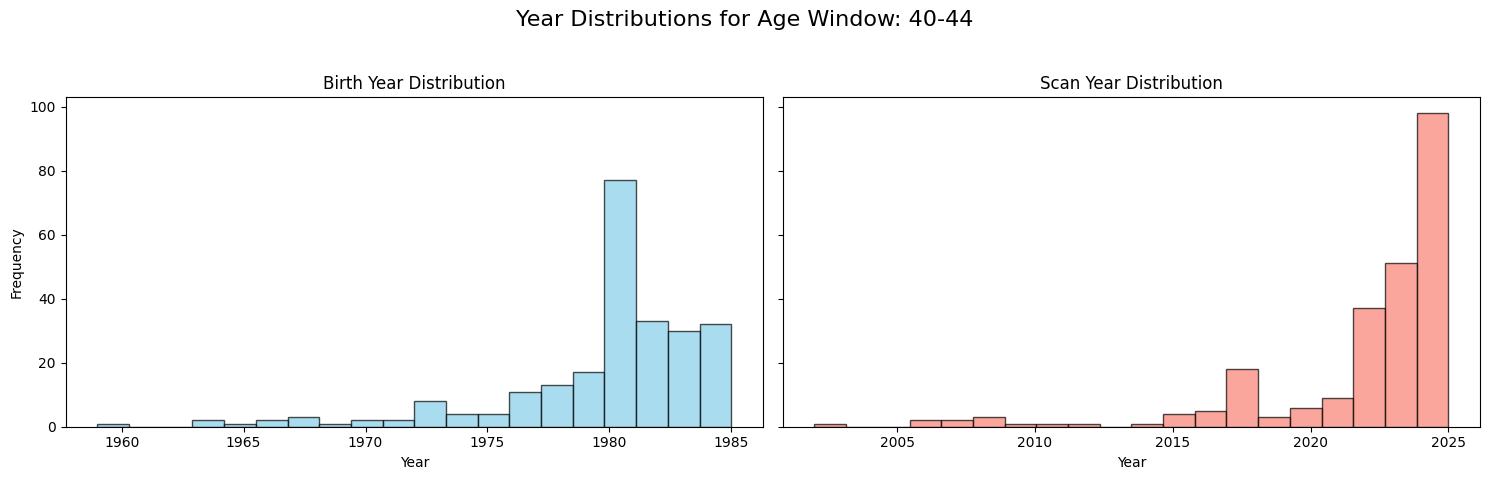

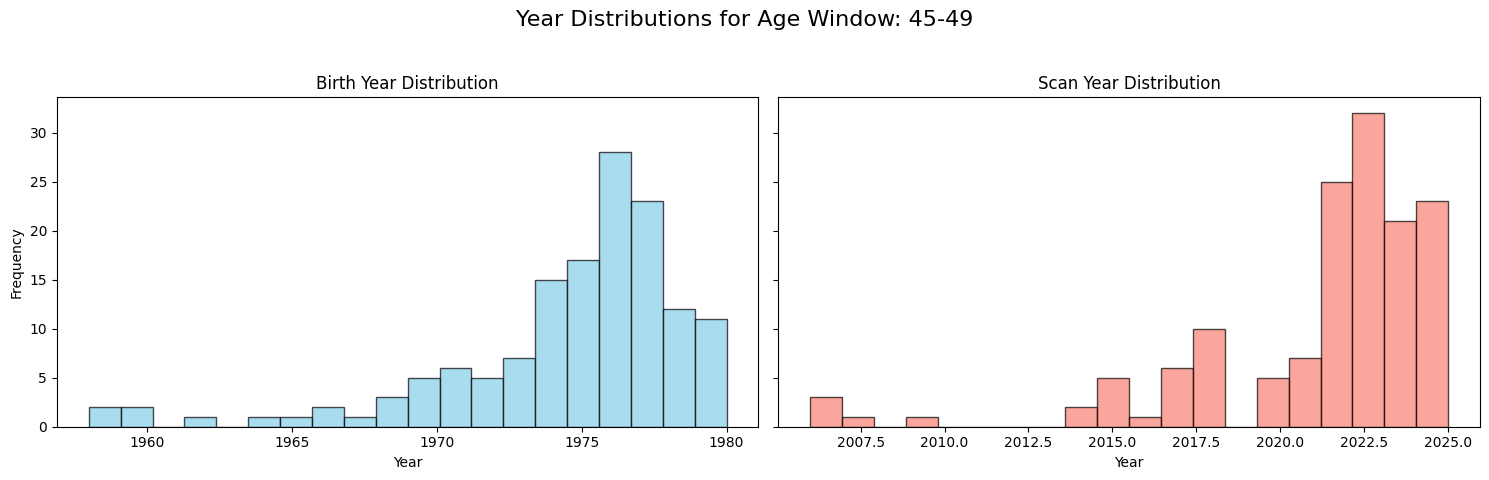

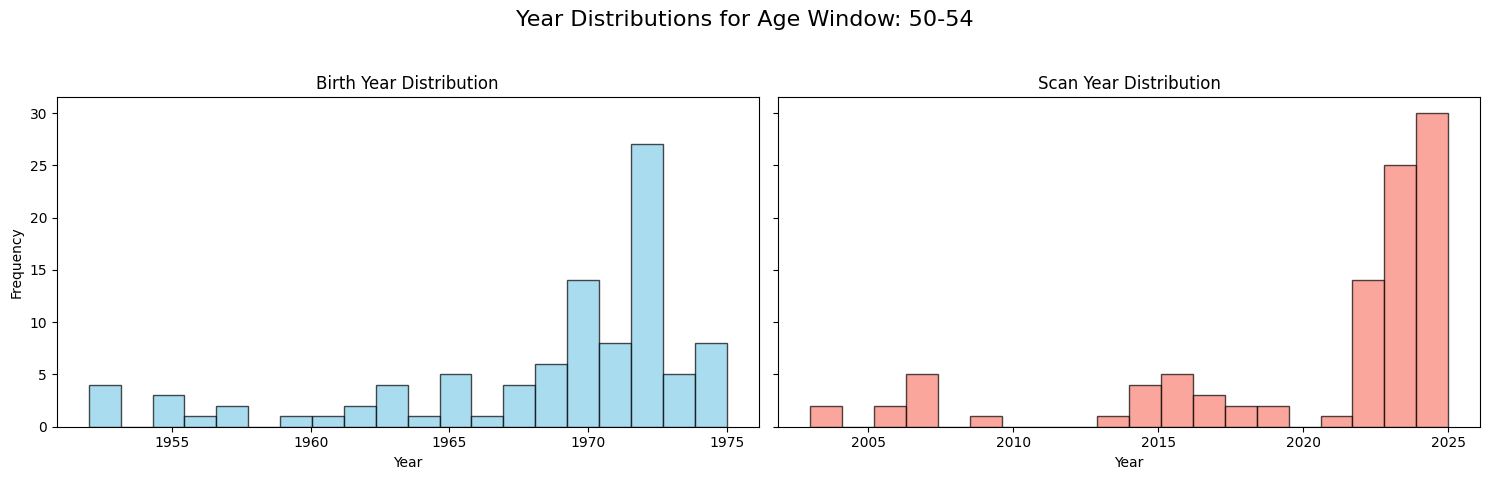

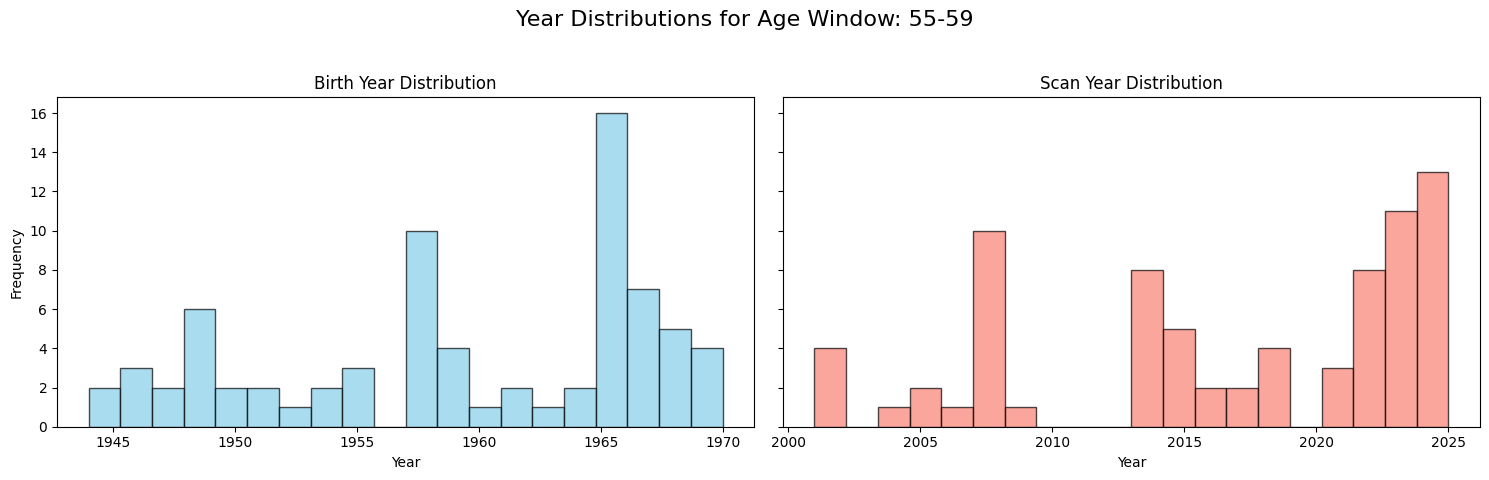

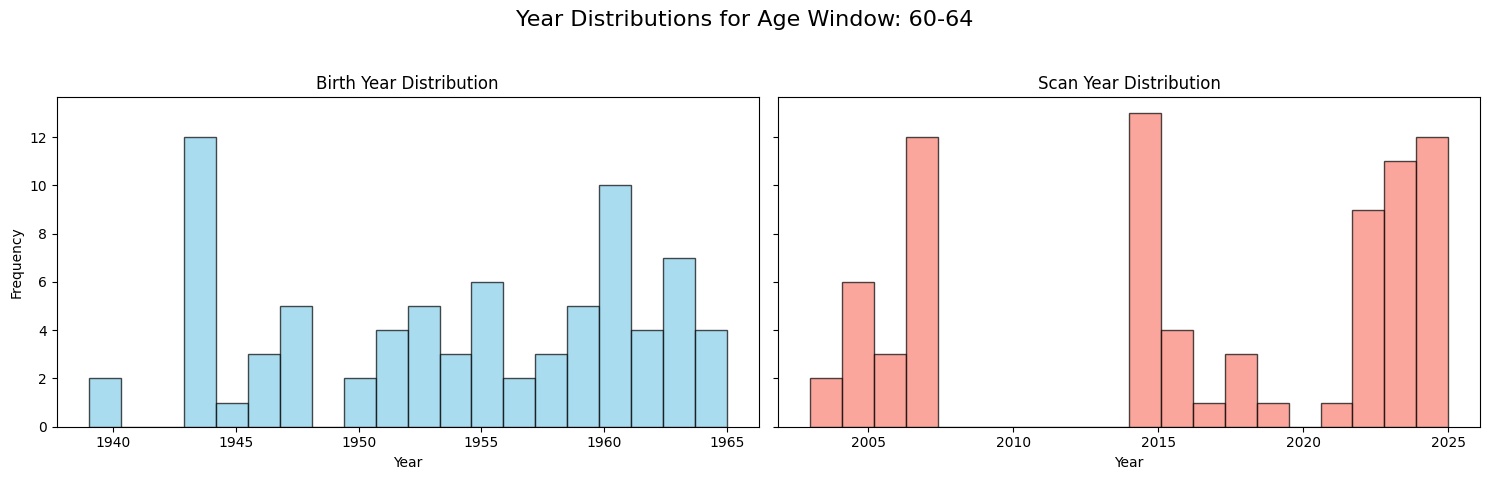

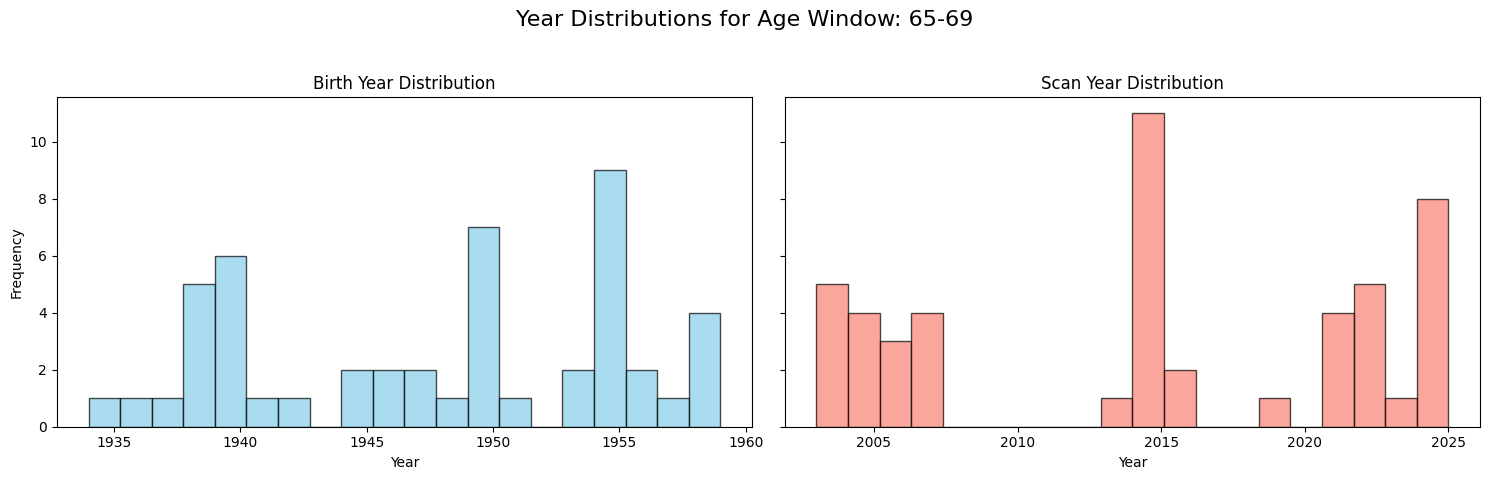

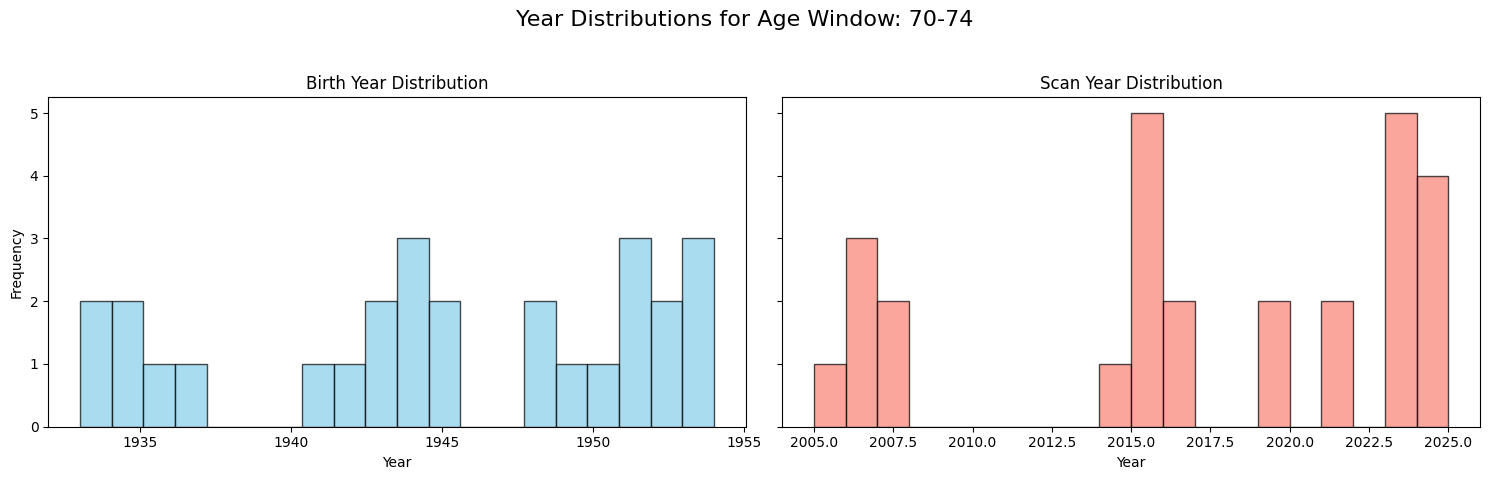

In [ ]:


import matplotlib.pyplot as plt

for age_window in age_windows:
    min_age, max_age = age_window
    filtered_df = good_scans[(good_scans['age_in_years'] >= min_age) & (good_scans['age_in_years'] <= max_age)]
    
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    fig.suptitle(f'Year Distributions for Age Window: {min_age}-{max_age}', fontsize=16)

    # Plot Birth Year in the first subplot
    axes[0].hist(filtered_df['birth_year'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Birth Year Distribution')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Frequency')

    # Plot Scan Year in the second subplot
    axes[1].hist(filtered_df['scan_year'], bins=20, color='salmon', edgecolor='black', alpha=0.7)
    axes[1].set_title('Scan Year Distribution')
    axes[1].set_xlabel('Year')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for the suptitle
    plt.show()